In [1]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#import dataset dan mengecek apakah data set sudah masuk  
df = pd.read_csv('dataset_tugas1_preprocessing.csv')
print(df.head())


      ID  Nama Jenis_Kelamin            Prodi Status Nilai_Akhir  \
0  MH001  Iwan     Laki-laki  Teknik Komputer  Aktif         NaN   
1  MH002   Eka     Perempuan  Teknik Komputer  Lulus           E   
2  MH003  Iwan     Laki-laki  Teknik Komputer  Aktif         NaN   
3  MH004   Eka     Perempuan  Teknik Komputer  Aktif           D   
4  MH005  Joko     Perempuan     Data Science  Aktif           C   

  Tanggal_Ujian  Umur  
0    13-04-2020   NaN  
1    2020/12/11  28.0  
2    2021/11/21  23.0  
3    2021/08/19  18.0  
4    2020/01/05  26.0  


In [2]:
#Eksplorasi awal (EDA)
#cek struktur tipe data 
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             99 non-null     object 
 1   Nama           99 non-null     object 
 2   Jenis_Kelamin  99 non-null     object 
 3   Prodi          99 non-null     object 
 4   Status         99 non-null     object 
 5   Nilai_Akhir    70 non-null     object 
 6   Tanggal_Ujian  99 non-null     object 
 7   Umur           90 non-null     float64
dtypes: float64(1), object(7)
memory usage: 6.3+ KB
None


In [6]:
#cek missing values
print(df.isnull().sum())

ID                0
Nama              0
Jenis_Kelamin     0
Prodi             0
Status            0
Nilai_Akhir      29
Tanggal_Ujian     0
Umur              9
dtype: int64


In [7]:
#statistik deskriptif
print(df.describe(include='all'))

           ID Nama Jenis_Kelamin            Prodi Status Nilai_Akhir  \
count      99   99            99               99     99          70   
unique     99   10             2                4      4           5   
top     MH001  Eka     Laki-laki  Teknik Komputer   Cuti           C   
freq        1   15            50               28     29          17   
mean      NaN  NaN           NaN              NaN    NaN         NaN   
std       NaN  NaN           NaN              NaN    NaN         NaN   
min       NaN  NaN           NaN              NaN    NaN         NaN   
25%       NaN  NaN           NaN              NaN    NaN         NaN   
50%       NaN  NaN           NaN              NaN    NaN         NaN   
75%       NaN  NaN           NaN              NaN    NaN         NaN   
max       NaN  NaN           NaN              NaN    NaN         NaN   

       Tanggal_Ujian       Umur  
count             99  90.000000  
unique            97        NaN  
top       2020/02/05        NaN  

In [18]:
#menangani missing values 
#mengisi missing value pada umur dengan mean
df['Umur']=df['Umur'].fillna(df['Umur'].mean())
#mengisi missing value pada nilai akhir dengan modus 
df['Nilai_Akhir']=df['Nilai_Akhir'].fillna(df['Nilai_Akhir'].mode()[0])
#cek ulang missing values
print (df.isnull().sum())

ID               0
Nama             0
Jenis_Kelamin    0
Prodi            0
Status           0
Nilai_Akhir      0
Tanggal_Ujian    0
Umur             0
dtype: int64


In [20]:
#normalisasi format tanggal 
df['Tanggal_Ujian'] = pd.to_datetime(
    df['Tanggal_Ujian'],
    errors='coerce',
    dayfirst=True)
#mengecek hasil normalisasi format tanggal 
print(df['Tanggal_Ujian'].head())

0   2020-04-13
1   2020-12-11
2   2021-11-21
3   2021-08-19
4   2020-01-05
Name: Tanggal_Ujian, dtype: datetime64[ns]


In [22]:
#Encoding Label
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
kolom_kategorikal = ['Nama','Jenis_Kelamin','Prodi','Status','Nilai_Akhir']
for col in kolom_kategorikal:
    df[col] = le.fit_transform(df[col])
#mengecek hasil encoding label 
print (df.head())

      ID  Nama  Jenis_Kelamin  Prodi  Status  Nilai_Akhir Tanggal_Ujian  \
0  MH001     8              0      3       0            2    2020-04-13   
1  MH002     4              1      3       3            4    2020-12-11   
2  MH003     8              0      3       0            2    2021-11-21   
3  MH004     4              1      3       0            3    2021-08-19   
4  MH005     9              1      0       0            2    2020-01-05   

        Umur  
0  23.366667  
1  28.000000  
2  23.000000  
3  18.000000  
4  26.000000  


In [32]:
#split data 
from sklearn.model_selection import train_test_split
X=df.drop('Status',axis=1)
y=df['Status']
X_train, X_test, y_train, y_test = train_test_split(
    X,Y,test_size=0.2,random_state=30)
#mengecek hasil split data
print("Jumlah data latih:", X_train.shape)
print("Jumlah data uji:", X_test.shape)

Jumlah data latih: (79, 6)
Jumlah data uji: (20, 6)


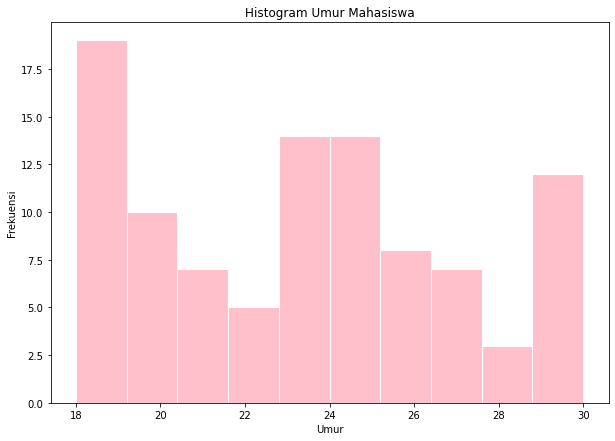

In [45]:
#histogram umur
plt.figure(figsize=(10,7))
plt.hist(df['Umur'], bins=10,color='pink',edgecolor='white')
plt.title('Histogram Umur Mahasiswa')
plt.xlabel('Umur')
plt.ylabel('Frekuensi')
plt.show()

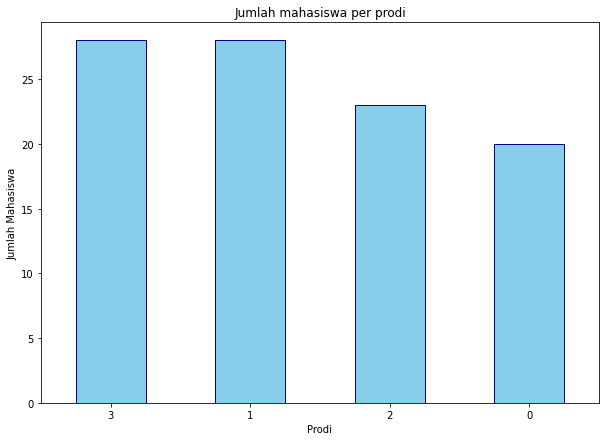

In [53]:
#grafik batang jumlah mahasiswa per prodi
plt.figure(figsize=(10,7))
df['Prodi'].value_counts().plot(kind='bar',color='skyblue',edgecolor='darkblue')
plt.xticks(rotation=0)
plt.title('Jumlah mahasiswa per prodi')
plt.xlabel('Prodi')
plt.ylabel('Jumlah Mahasiswa')
plt.show()